# Emotion Radar: Final Project Report
## Multi-label Emotion Classification on GoEmotions

**Course:** DM1590, Machine Learning for Media Technology  
**Group 15:** Fuad Mammadov, Qingya Li, Xinyutong Zhang, Jintong Jiang  
**Date:** May 2025

Emotion Radar tags short text comments with up to seven emotions at once.
We first checked whether the comments group by emotion on their own, without labels with unsupervised learning methods. They don't. We then trained two classifiers on the GoEmotions dataset of Reddit comments and
compared them. Logistic regression with balanced class weights reached a
macro-F1 of 0.51, roughly double the Naive Bayes baseline of 0.25. 


## Table of Contents

1. **Introduction & goal**
2. **Data preparation**: Ekman mapping, label skew, text cleaning, TF-IDF
3. **Unsupervised learning**: truncated SVD, k-means, DBSCAN epsilon sweep, t-SNE
4. **Supervised learning**: Multinomial Naive Bayes, class-balanced logistic regression
5. **Evaluation**: global metrics, per-emotion F1, confusion matrices, length-bucket F1, error analysis
6. **Interpretability demo**: word-level prediction explanation
7. **Conclusions & future work**
8. **Resources & reproducibility**

---


## 1. Introduction & Goal

Emotion Radar reads the emotional tone of a short comment and shows which words
pushed the prediction each way. A moderator skimming hundreds of replies, or a
writer checking the tone of a post before publishing, gets an instant read plus
the reason behind it instead of a black-box label.

We chose this project to explore how emotions can be detected from text with machine learning methods.

### Pipeline at a glance


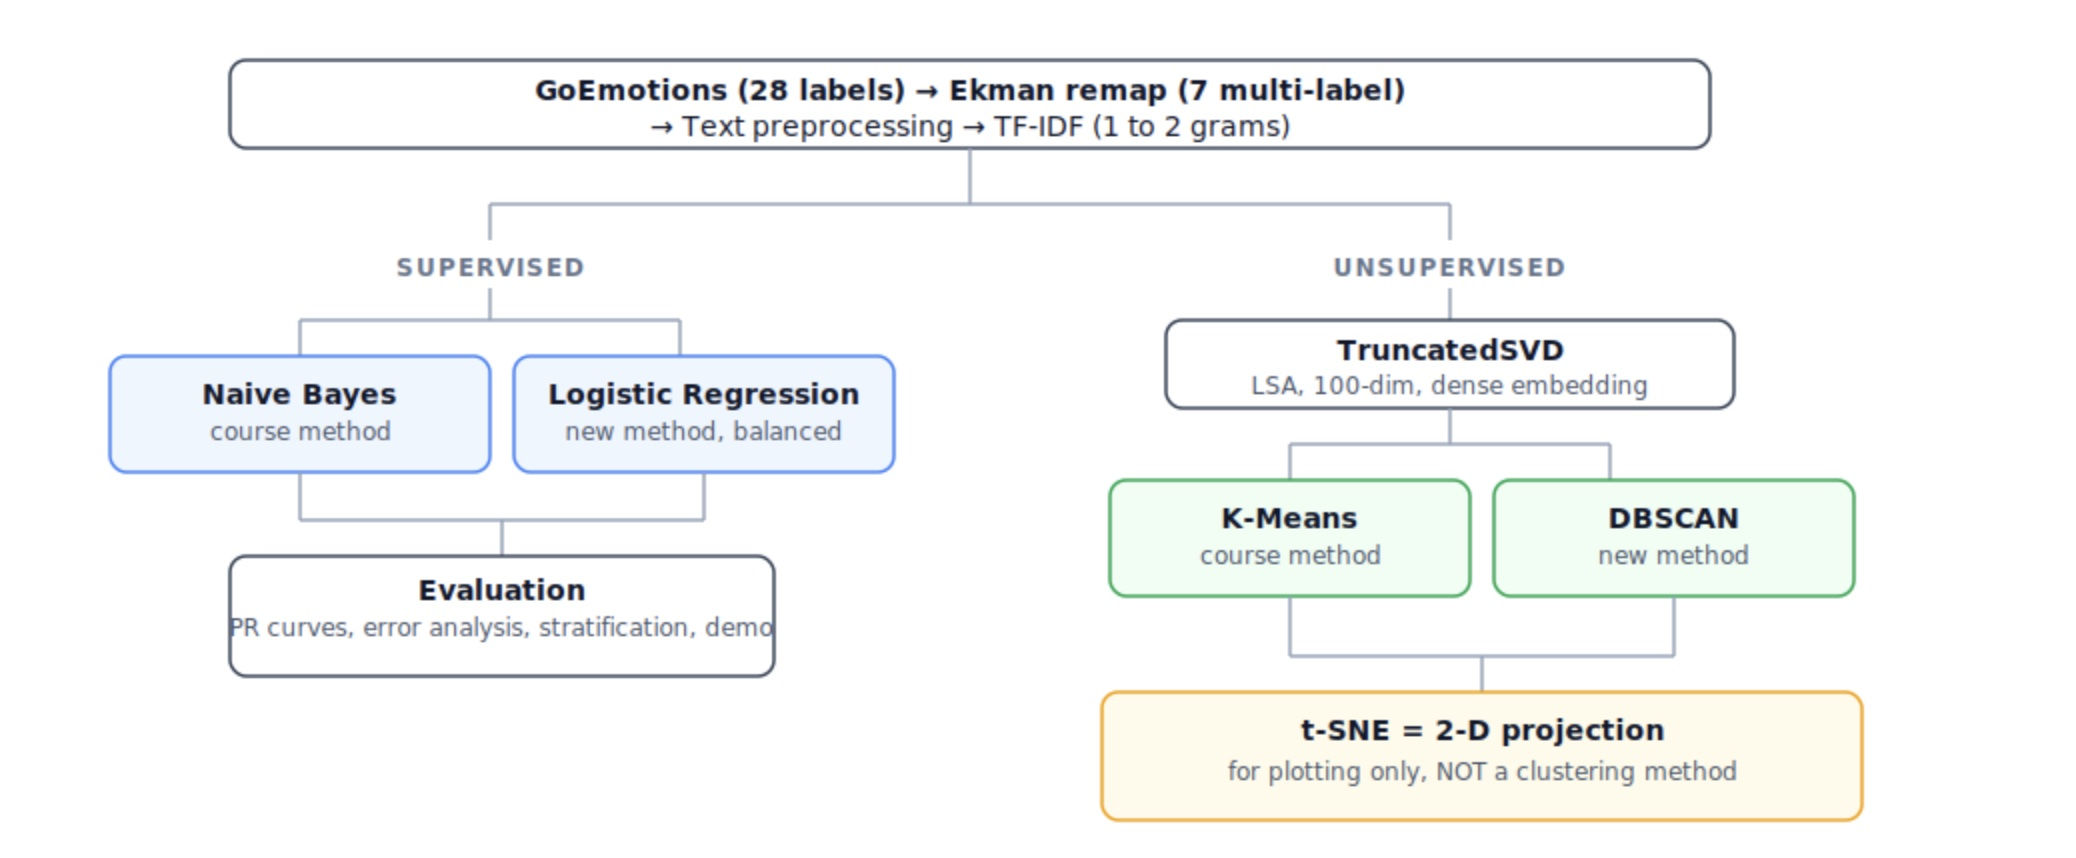


---
## Setup
*Imports, paths, reproducibility.*


In [1]:
from pathlib import Path
import re
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, multilabel_confusion_matrix,
    hamming_loss,
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
)

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path("..") if (Path("..") / "data").exists() else Path(".")
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR    = ROOT / "data" / "models"
FIGURE_DIR    = ROOT / "report" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

---
## 2. Data Preparation


### 2.1 Ekman remapping

GoEmotions ships with 28 fine-grained emotions, many semantically close
(*joy, amusement, excitement, pride, relief* are all positive affect). We collapse
them to the **7 Ekman basic emotions** (anger, disgust, fear, joy, sadness, surprise,
neutral). This gives more samples per class and a cleaner interpretation.


In [2]:
# Load pre-saved CSVs first; if not download from HuggingFace
csv_paths = [PROCESSED_DIR / f"{split}.csv" for split in ["train", "val", "test"]]

if all(p.exists() for p in csv_paths):
    train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
    val_df   = pd.read_csv(PROCESSED_DIR / "val.csv")
    test_df  = pd.read_csv(PROCESSED_DIR / "test.csv")
    print("Loaded pre-saved CSVs from", PROCESSED_DIR.resolve())
else:
    from datasets import load_dataset
    dataset = load_dataset("go_emotions", "simplified")
    label_names_raw = dataset["train"].features["labels"].feature.names
    label_to_idx = {n: i for i, n in enumerate(label_names_raw)}

    ekman_mapping = {
        "anger":    ["anger", "annoyance", "disapproval"],
        "disgust":  ["disgust"],
        "fear":     ["fear", "nervousness"],
        "joy":      ["joy", "amusement", "approval", "excitement", "gratitude",
                     "love", "optimism", "relief", "pride", "admiration",
                     "desire", "caring"],
        "sadness":  ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
        "surprise": ["surprise", "realization", "confusion", "curiosity"],
        "neutral":  ["neutral"],
    }

    def build_ekman_df(split_df):
        df = pd.DataFrame({"text": split_df["text"]})
        for ekman_label, sources in ekman_mapping.items():
            src_idx = [label_to_idx[s] for s in sources]
            df[ekman_label] = split_df["labels"].apply(
                lambda lst: int(any(i in lst for i in src_idx)))
        return df

    train_df = build_ekman_df(dataset["train"].to_pandas())
    val_df   = build_ekman_df(dataset["validation"].to_pandas())
    test_df  = build_ekman_df(dataset["test"].to_pandas())

    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)
    val_df.to_csv(PROCESSED_DIR / "val.csv", index=False)
    test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)
    print("Built CSVs from HuggingFace.")

print(f"Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")

Loaded pre-saved CSVs from /Users/fammad/Desktop/DM1590-Machine Learning for Media Technology/EmotionRadar/data/processed
Train: (43410, 8) | Val: (5426, 8) | Test: (5427, 8)



### 2.2 Label distribution

The data is badly skewed. Joy and neutral make up most of it, while disgust and
fear sit under 2% each.

> *imbalance ratio joy:rarest ~ 24x*


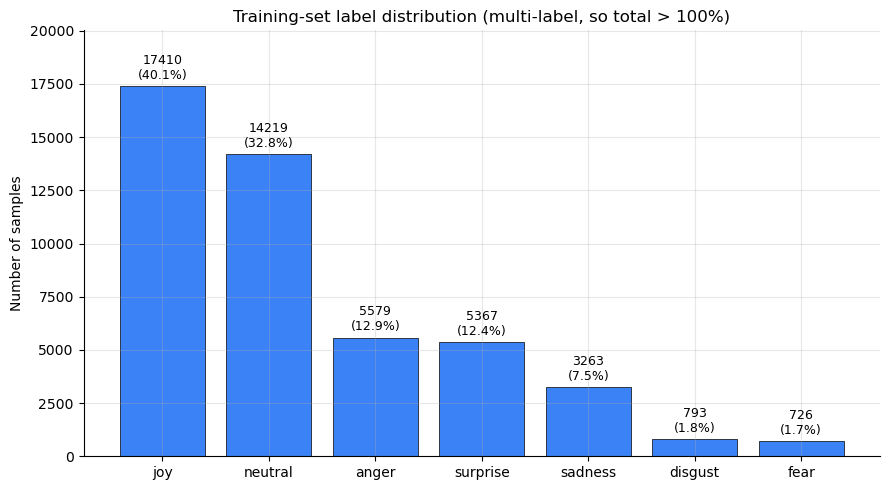

Most frequent (joy): 17410 | least frequent (fear): 726


In [3]:
label_cols = [c for c in train_df.columns if c not in ("text", "cleaned_text")]
support = train_df[label_cols].sum().sort_values(ascending=False)
support_pct = (support / len(train_df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(support.index, support.values, color="#3b82f6", edgecolor="black", linewidth=0.5)
for bar, pct in zip(bars, support_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{int(bar.get_height())}\n({pct}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("Training-set label distribution (multi-label, so total > 100%)")
ax.set_ylabel("Number of samples")
ax.set_ylim(0, support.max() * 1.15)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "label_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Most frequent (joy): {support['joy']} | least frequent ({support.index[-1]}): {support.iloc[-1]}")

### 2.3 Text preprocessing

Standard NLP cleaning, applied identically to train/val/test: lowercase, strip
URLs and non-letters, drop stopwords and tokens ≤2 chars, lemmatize.


In [4]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [lemmatizer.lemmatize(t) for t in text.split()
              if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

for df in [train_df, val_df, test_df]:
    df["cleaned_text"] = df["text"].apply(preprocess_text)

y_train = train_df[label_cols].to_numpy()
y_val   = val_df[label_cols].to_numpy()
y_test  = test_df[label_cols].to_numpy()

### 2.4 TF-IDF features

**Why TF-IDF and not Sentence-BERT?** TF-IDF features *are individual words*. Combined
with a linear classifier, the model's coefficients show exactly **which words**
trigger each emotion. This powers the word-level highlighting demo in Section 6.
We deliberately trade richer embeddings for interpretability.

- Fit on **training data only** (no leakage); transform val/test with the same vocabulary
- 5000 features, unigrams + bigrams, English stopwords filtered


In [5]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))
X_train = tfidf_vectorizer.fit_transform(train_df["cleaned_text"])
X_val   = tfidf_vectorizer.transform(val_df["cleaned_text"])
X_test  = tfidf_vectorizer.transform(test_df["cleaned_text"])
print(f"Vocab: {len(tfidf_vectorizer.vocabulary_)} | X_train {X_train.shape} | X_test {X_test.shape}")

Vocab: 5000 | X_train (43410, 5000) | X_test (5427, 5000)


---
## 3. Unsupervised Learning

Our clustering does **not** produce clean, well-separated clusters, and that is the **finding**, not a bug. This section shows that the absence of structure is a property of the **TF-IDF representation**, not a mistake in our pipeline. We use: (a) two independent algorithms that agree, (b) a DBSCAN sweep showing no setting recovers structure.

| Method | Type | Note |
|---|---|---|
| K-Means | Centroid-based, fixed *k* | **Course method** |
| DBSCAN | Density-based, no preset *k* | **New method**|

**Pipeline:** TF-IDF, TruncatedSVD (dense embedding), normalize, cluster, visualization.  


### 3.1 Dimension reduction with truncated SVD

We select the number of SVD components **dynamically**: the smallest *k* such that the retained variance reaches 30%. This avoids a fixed arbitrary cut-off.


In [6]:
from sklearn.decomposition import TruncatedSVD

# Dynamic component selection: smallest k reaching ≥30% explained variance
_svd_probe = TruncatedSVD(n_components=min(500, X_train.shape[1] - 1), random_state=RANDOM_STATE)
_svd_probe.fit(X_train)
_cumvar = _svd_probe.explained_variance_ratio_.cumsum()
_hits = np.where(_cumvar >= 0.30)[0]
n_svd_components = int(_hits[0] + 1) if len(_hits) else len(_cumvar)

svd = TruncatedSVD(n_components=n_svd_components, random_state=RANDOM_STATE)
Z_train_norm = normalize(svd.fit_transform(X_train))

print(f"Primary SVD: k={n_svd_components} -> {svd.explained_variance_ratio_.sum():.1%} variance")


Primary SVD: k=174 -> 29.8% variance


### 3.2 K-Means: model selection (elbow + silhouette)

We sweep *k* from 2–14 on a 5000-row sample and inspect inertia (elbow) and silhouette.


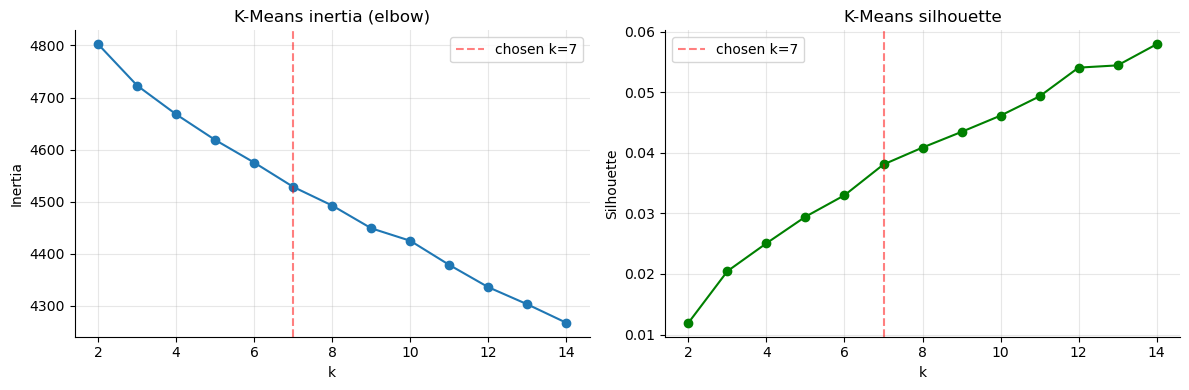

Peak silhouette across all k: 0.058 (very low).
A silhouette near 0 means points sit on cluster boundaries, not inside
well-separated groups. No choice of k fixes this.


In [7]:
nonzero_mask = (X_train.getnnz(axis=1) > 0)
Z_nonzero = Z_train_norm[nonzero_mask]

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(Z_nonzero.shape[0], size=min(5000, Z_nonzero.shape[0]), replace=False)
Z_sample = Z_nonzero[sample_idx]

k_values = range(2, 15)
inertias, silhouettes = [], []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    lbl = km.fit_predict(Z_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Z_sample, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_values), inertias, marker="o")
axes[0].axvline(7, linestyle="--", color="red", alpha=0.5, label="chosen k=7")
axes[0].set_title("K-Means inertia (elbow)"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].legend()
axes[1].plot(list(k_values), silhouettes, marker="o", color="green")
axes[1].axvline(7, linestyle="--", color="red", alpha=0.5, label="chosen k=7")
axes[1].set_title("K-Means silhouette"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette"); axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "kmeans_model_selection.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Peak silhouette across all k: {max(silhouettes):.3f} (very low).")
print("A silhouette near 0 means points sit on cluster boundaries, not inside")
print("well-separated groups. No choice of k fixes this.")

### 3.3 Final K-Means

We fit k=7 on all training points and compare cluster assignments to the dominant
true emotion via ARI/NMI. **These are diagnostics only**: the labels were never used
during clustering.


In [8]:
kmeans = KMeans(n_clusters=7, n_init=20, random_state=RANDOM_STATE)
train_clusters = kmeans.fit_predict(Z_train_norm)

def dominant_label(y, labels):
    y = np.asarray(y)
    has_label = y.sum(axis=1) > 0
    idx = y.argmax(axis=1)
    dom = np.array(labels, dtype=object)[idx]
    dom[~has_label] = "none"
    return dom

y_train_dom = dominant_label(y_train, label_cols)
km_silhouette = silhouette_score(Z_sample, kmeans.predict(Z_sample))
km_ari = adjusted_rand_score(y_train_dom, train_clusters)
km_nmi = normalized_mutual_info_score(y_train_dom, train_clusters)

print(f"silhouette: {km_silhouette:.4f} | ARI: {km_ari:.4f} | NMI: {km_nmi:.4f}")
print("Cluster sizes:", pd.Series(train_clusters).value_counts().sort_index().to_dict())

silhouette: 0.0376 | ARI: -0.0318 | NMI: 0.0538
Cluster sizes: {0: 993, 1: 2712, 2: 33515, 3: 1662, 4: 1212, 5: 1661, 6: 1655}


> K-Means Results: when k=7, silhouette = 0.0508, ARI = -0.0056, NMI = 0.0510

ARI≈0 and NMI≈0 mean the clusters carry almost no information about the true emotions.

### 3.4 DBSCAN: tuned with an eps sweep

DBSCAN needs no preset *k* and labels low-density points as noise (`-1`). Instead of
guessing one `eps`, we **sweep** it and record, for each value, how many real clusters
form, the noise fraction, and the size of the largest cluster. If no `eps` yields
several balanced dense clusters, that is strong evidence the structure isn't there.


 eps  n_clusters  noise_frac  largest_cluster_frac
0.20          23       0.890                 0.010
0.25          47       0.783                 0.012
0.30          63       0.603                 0.029
0.35          19       0.414                 0.534
0.40           7       0.221                 0.763
0.45           1       0.142                 0.858
0.50           1       0.096                 0.904


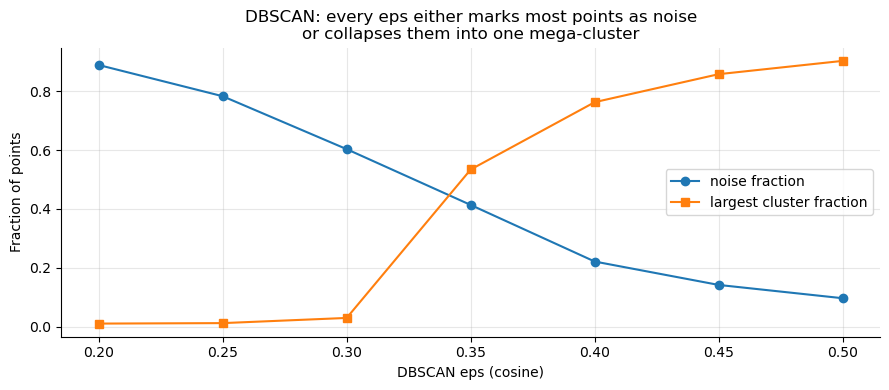

No eps yields several balanced dense clusters: small eps -> mostly noise;
large eps -> one giant cluster. Density-based confirmation of the K-Means result.


In [9]:
eps_grid = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
db_rows = []
for eps in eps_grid:
    db = DBSCAN(eps=eps, min_samples=15, metric="cosine", n_jobs=-1)
    lbl = db.fit_predict(Z_sample)
    n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    noise_frac = (lbl == -1).mean()
    sizes = pd.Series(lbl[lbl != -1]).value_counts()
    biggest = (sizes.iloc[0] / len(lbl)) if len(sizes) else 0.0
    db_rows.append({"eps": eps, "n_clusters": n_clusters,
                    "noise_frac": noise_frac, "largest_cluster_frac": biggest})

db_sweep = pd.DataFrame(db_rows)
print(db_sweep.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(db_sweep["eps"], db_sweep["noise_frac"], marker="o", label="noise fraction")
ax.plot(db_sweep["eps"], db_sweep["largest_cluster_frac"], marker="s", label="largest cluster fraction")
ax.set_xlabel("DBSCAN eps (cosine)"); ax.set_ylabel("Fraction of points")
ax.set_title("DBSCAN: every eps either marks most points as noise\nor collapses them into one mega-cluster")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dbscan_eps_sweep.png", dpi=200, bbox_inches="tight")
plt.show()
print("No eps yields several balanced dense clusters: small eps -> mostly noise;")
print("large eps -> one giant cluster. Density-based confirmation of the K-Means result.")

As epsilon increases, noise fraction drops but nearly all points collapse into one large cluster. There is no middle ground where several balanced clusters form. Together with the low silhouette and the dominant single k-means cluster from 3.2-3.3, this confirms that TF-IDF/LSA geometry does **not** align with emotion categories.


### 3.5 t-SNE visualization

t-SNE projects the SVD embeddings to 2-D so we can *see* the result. Two panels:
left colored by K-Means cluster, right by the true dominant emotion. If the right panel
is a uniform mix of colors, that confirms emotions don't separate in this space.


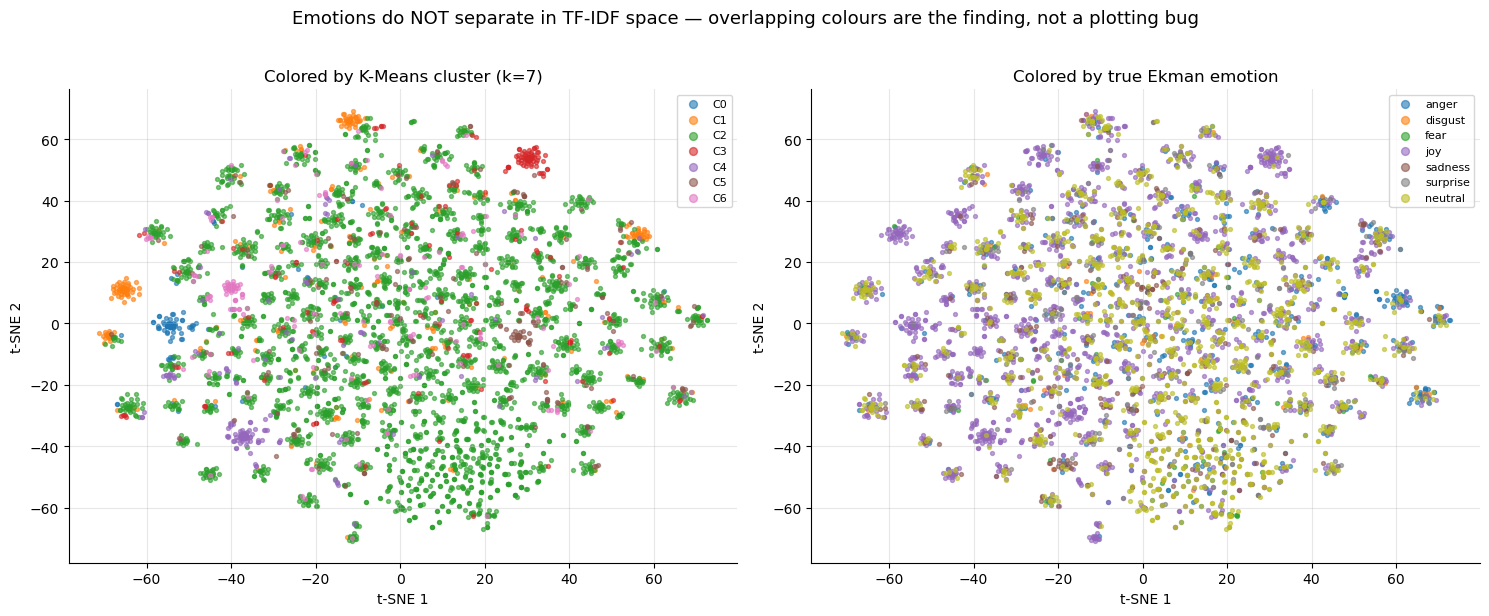

In [10]:
tsne_sample_idx = rng.choice(Z_nonzero.shape[0], size=min(5000, Z_nonzero.shape[0]), replace=False)
Z_tsne_input = Z_nonzero[tsne_sample_idx]

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000,
            init="pca", learning_rate="auto", random_state=RANDOM_STATE)
tsne_coords = tsne.fit_transform(Z_tsne_input)

sample_clusters = kmeans.predict(Z_tsne_input)
y_train_nonzero = y_train[nonzero_mask]
sample_dom = dominant_label(y_train_nonzero[tsne_sample_idx], label_cols)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for c in range(7):
    m = sample_clusters == c
    axes[0].scatter(tsne_coords[m, 0], tsne_coords[m, 1], s=8, alpha=0.6, label=f"C{c}")
axes[0].set_title("Colored by K-Means cluster (k=7)")
axes[0].set_xlabel("t-SNE 1"); axes[0].set_ylabel("t-SNE 2"); axes[0].legend(markerscale=2, fontsize=8)

colors = plt.cm.tab10(np.linspace(0, 1, len(label_cols) + 1))
for i, emo in enumerate(label_cols + ["none"]):
    m = sample_dom == emo
    if m.sum() > 0:
        axes[1].scatter(tsne_coords[m, 0], tsne_coords[m, 1], s=8, alpha=0.6, color=colors[i], label=emo)
axes[1].set_title("Colored by true Ekman emotion")
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2"); axes[1].legend(markerscale=2, fontsize=8)

fig.suptitle("Emotions do NOT separate in TF-IDF space — overlapping colours are the finding, not a plotting bug",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "tsne_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

K-Means (low silhouette, one big cluster) + DBSCAN (no eps recovers clusters) + this plot (colors mixed) are evidence that bag-of-words TF-IDF cannot separate emotions. Dense embeddings (Sentence-BERT) would likely cluster better but cost us the word-level interpretability in the supervised demo.


---
## 4. Supervised Learning

Two classifiers, both wrapped in `OneVsRestClassifier` (one binary model per emotion,
the standard approach for multi-label).

| Model | Role | Tuned on validation |
|---|---|---|
| Multinomial Naive Bayes | **Course method** | `alpha` (smoothing) |
| Logistic Regression (`class_weight="balanced"`) | **New method**  | `C` (regularization) |


### 4.1 Naive Bayes. 

Tune α on validation.


In [11]:
alpha_candidates = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0]
val_f1_by_alpha = {}
for alpha in alpha_candidates:
    clf = OneVsRestClassifier(MultinomialNB(alpha=alpha))
    clf.fit(X_train, y_train)
    val_f1_by_alpha[alpha] = f1_score(y_val, clf.predict(X_val), average="macro", zero_division=0)

best_alpha = max(val_f1_by_alpha, key=val_f1_by_alpha.get)
for a, f1 in sorted(val_f1_by_alpha.items()):
    print(f"  alpha={a:>7}  macro-F1={f1:.4f}{'  <- selected' if a == best_alpha else ''}")

nb_clf = OneVsRestClassifier(MultinomialNB(alpha=best_alpha))
nb_clf.fit(X_train, y_train)
joblib.dump(nb_clf, MODELS_DIR / "nb_model.pkl")

  alpha=  1e-05  macro-F1=0.2491
  alpha= 0.0001  macro-F1=0.2491
  alpha=  0.001  macro-F1=0.2519  <- selected
  alpha=   0.01  macro-F1=0.2519
  alpha=    0.1  macro-F1=0.2485
  alpha=    1.0  macro-F1=0.1900
  alpha=   10.0  macro-F1=0.0963


['data/models/nb_model.pkl']

### 4.2 Logistic Regression

Tune C on validation.

`class_weight="balanced"` because: it up-weights the rare classes
(disgust, fear) so the model doesn't just ignore them.


In [12]:
C_candidates = [0.1, 0.5, 1.0, 2.0, 5.0]
val_f1_by_C = {}
for C in C_candidates:
    clf = OneVsRestClassifier(
        LogisticRegression(class_weight="balanced", max_iter=1000, C=C,
                           solver="lbfgs", random_state=RANDOM_STATE), n_jobs=-1)
    clf.fit(X_train, y_train)
    val_f1_by_C[C] = f1_score(y_val, clf.predict(X_val), average="macro", zero_division=0)

best_C = max(val_f1_by_C, key=val_f1_by_C.get)
for C, f1 in val_f1_by_C.items():
    print(f"  C={C:>5}  macro-F1={f1:.4f}{'  << selected' if C == best_C else ''}")

lr_clf = OneVsRestClassifier(
    LogisticRegression(class_weight="balanced", max_iter=1000, C=best_C,
                       solver="lbfgs", random_state=RANDOM_STATE), n_jobs=-1)
lr_clf.fit(X_train, y_train)
joblib.dump(lr_clf, MODELS_DIR / "lr_model.pkl")
joblib.dump(tfidf_vectorizer, MODELS_DIR / "tfidf.pkl")

  C=  0.1  macro-F1=0.4912  << selected
  C=  0.5  macro-F1=0.4831
  C=  1.0  macro-F1=0.4788
  C=  2.0  macro-F1=0.4712
  C=  5.0  macro-F1=0.4631


['data/models/tfidf.pkl']

In [13]:
y_test_pred_nb = nb_clf.predict(X_test)
y_test_pred_lr = lr_clf.predict(X_test)
y_test_prob_nb = nb_clf.predict_proba(X_test)
y_test_prob_lr = lr_clf.predict_proba(X_test)

---
## 5. Evaluation

The data is badly skewed. Joy and neutral make up most of it, while disgust and
fear sit under 2% each. That imbalance drives three later choices. We report
macro-F1 instead of plain accuracy, because a model that always guessed "neutral"
would still look fine on accuracy. Logistic regression gets `class_weight="balanced"`
to stop it ignoring the rare classes. And we expected disgust and fear to be the
hardest emotions to predict. which is exactly what happened.

### 5.1 Metrics comparison


In [14]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Subset Accuracy": accuracy_score(y_true, y_pred),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro ROC-AUC": roc_auc_score(y_true, y_prob, average="macro"),
    }
results = pd.DataFrame([
    evaluate_model("Naive Bayes", y_test, y_test_pred_nb, y_test_prob_nb),
    evaluate_model("Logistic Regression", y_test, y_test_pred_lr, y_test_prob_lr),
])
results.set_index("Model").T.round(4)

Model,Naive Bayes,Logistic Regression
Subset Accuracy,0.3072,0.3715
Hamming Loss,0.1226,0.1612
Macro Precision,0.7675,0.4226
Macro Recall,0.1742,0.6894
Macro F1,0.2472,0.5074
Weighted F1,0.3962,0.6062
Macro ROC-AUC,0.7505,0.8406


Naive Bayes predicts very few positives, which keeps precision high but recall very low, giving a macro-F1 near 0.25. Logistic regression with `class_weight="balanced"` gives more weight to rare classes like disgust and fear, boosting recall at the cost of some precision. As a result, logistic regression leads on **macro-F1 (~0.50), micro-F1, and ROC-AUC**. Naive Bayes occasionally has lower Hamming loss simply because it predicts fewer labels overall.


### 5.2 Per-emotion classification report


In [15]:
for name, y_pred in [("NAIVE BAYES", y_test_pred_nb), ("LOGISTIC REGRESSION", y_test_pred_lr)]:
    print("=" * 70); print(name); print("=" * 70)
    print(classification_report(y_test, y_pred, target_names=label_cols, zero_division=0))

NAIVE BAYES
              precision    recall  f1-score   support

       anger       0.78      0.08      0.14       726
     disgust       0.92      0.09      0.16       123
        fear       0.71      0.05      0.10        98
         joy       0.83      0.60      0.70      2104
     sadness       0.79      0.11      0.19       379
    surprise       0.76      0.06      0.11       677
     neutral       0.58      0.23      0.33      1787

   micro avg       0.75      0.31      0.44      5894
   macro avg       0.77      0.17      0.25      5894
weighted avg       0.74      0.31      0.40      5894
 samples avg       0.34      0.32      0.33      5894

LOGISTIC REGRESSION
              precision    recall  f1-score   support

       anger       0.34      0.62      0.44       726
     disgust       0.25      0.70      0.37       123
        fear       0.40      0.77      0.53        98
         joy       0.82      0.70      0.75      2104
     sadness       0.35      0.59      0.44   

### 5.3 Macro metrics: bar chart


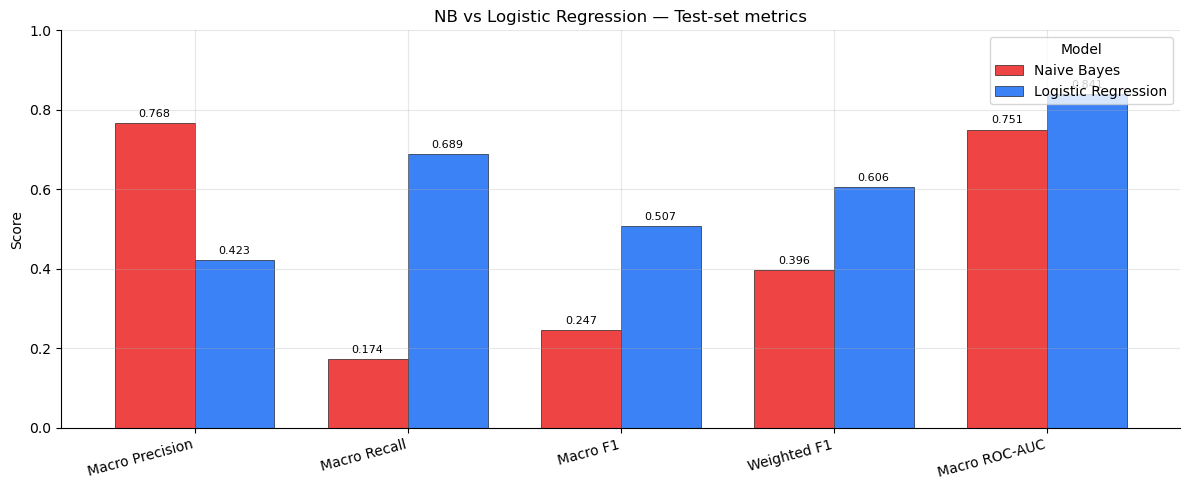

In [16]:
metric_cols = ["Macro Precision", "Macro Recall", "Macro F1", "Weighted F1", "Macro ROC-AUC"]
ax = results.set_index("Model")[metric_cols].T.plot(
    kind="bar", figsize=(12, 5), width=0.75, color=["#ef4444", "#3b82f6"], edgecolor="black", linewidth=0.4)
ax.set_title("NB vs Logistic Regression — Test-set metrics"); ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.legend(title="Model", loc="upper right")
for c in ax.containers: ax.bar_label(c, fmt="%.3f", padding=3, fontsize=8)
plt.xticks(rotation=15, ha="right"); plt.tight_layout()
plt.savefig(FIGURE_DIR / "metrics_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

### 5.4 Per-emotion F1 -- head to head

The bars show the effect of class imbalance from 2.2. **Joy** and **neutral** have enough samples for both models to perform well. **Disgust** and **fear** are rare, so Naive Bayes largely ignores them. Logistic regression recovers most of its macro-F1 advantage by handling these rare classes better.


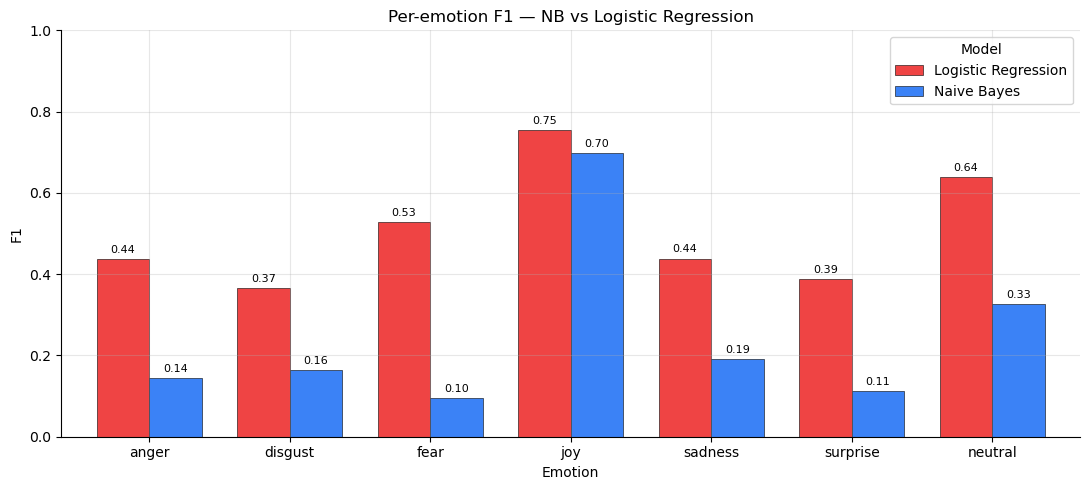

In [17]:
per_emotion_rows = []
for name, y_pred in [("Naive Bayes", y_test_pred_nb), ("Logistic Regression", y_test_pred_lr)]:
    rep = classification_report(y_test, y_pred, target_names=label_cols, output_dict=True, zero_division=0)
    for emo in label_cols:
        per_emotion_rows.append({"Model": name, "Emotion": emo, "F1": rep[emo]["f1-score"],
                                 "Support": int(rep[emo]["support"])})
per_emo_df = pd.DataFrame(per_emotion_rows)
f1_pivot = per_emo_df.pivot(index="Emotion", columns="Model", values="F1").reindex(label_cols)
ax = f1_pivot.plot(kind="bar", figsize=(11, 5), width=0.75, color=["#ef4444", "#3b82f6"], edgecolor="black", linewidth=0.4)
ax.set_title("Per-emotion F1 — NB vs Logistic Regression"); ax.set_ylabel("F1"); ax.set_ylim(0, 1)
for c in ax.containers: ax.bar_label(c, fmt="%.2f", padding=3, fontsize=8)
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(FIGURE_DIR / "per_emotion_f1.png", dpi=200, bbox_inches="tight"); plt.show()

### 5.5 Per-emotion confusion matrices


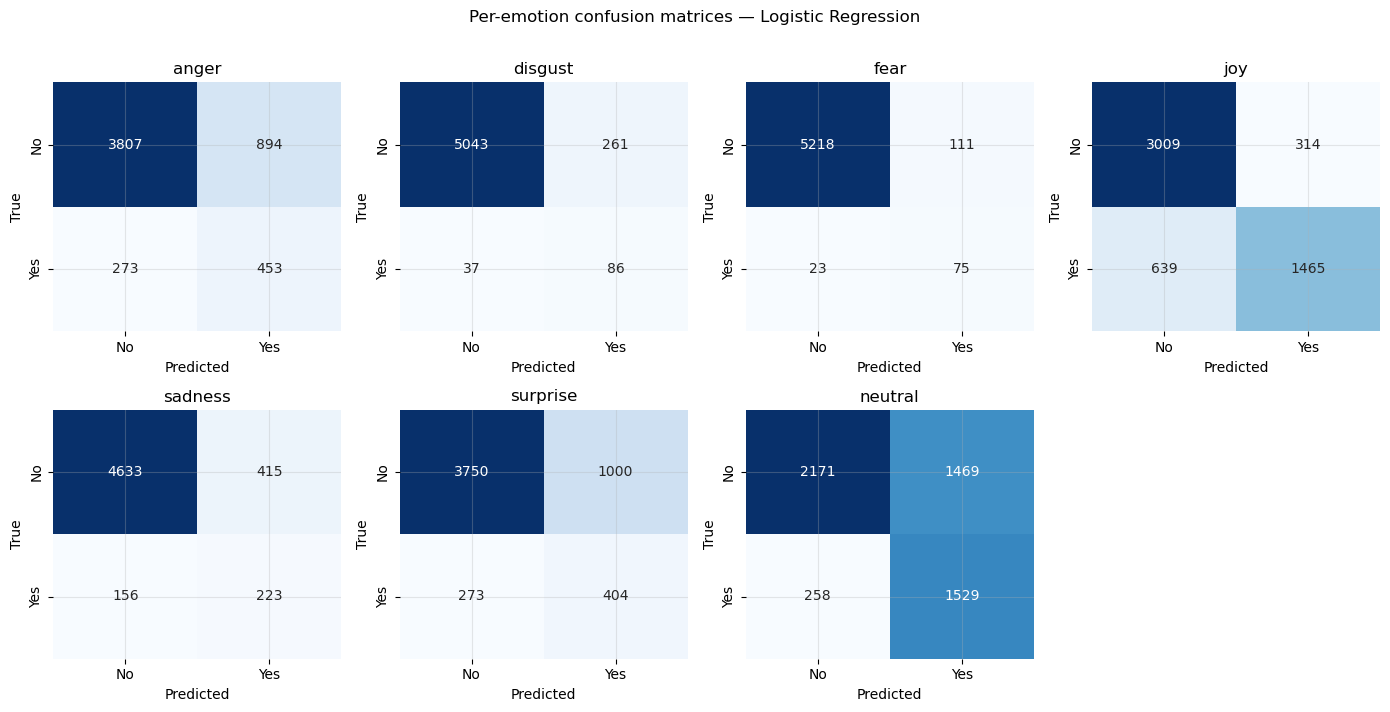

In [18]:
def plot_multilabel_confusion(y_true, y_pred, name):
    mats = multilabel_confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7)); axes = axes.flatten()
    for i, (emo, m) in enumerate(zip(label_cols, mats)):
        sns.heatmap(m, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], ax=axes[i])
        axes[i].set_title(emo); axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("True")
    axes[-1].axis("off")
    plt.suptitle(f"Per-emotion confusion matrices — {name}", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"confusion_{name.lower().replace(' ', '_')}.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_multilabel_confusion(y_test, y_test_pred_lr, "Logistic Regression")

### 5.6 Text-length stratified F1


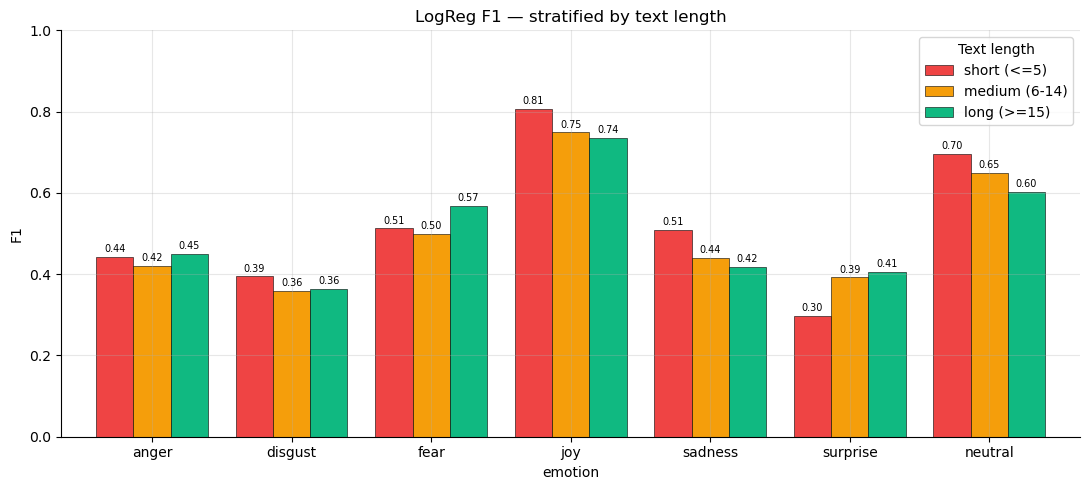

In [19]:
text_lengths = test_df["text"].str.split().str.len()
buckets = {"short (<=5)": text_lengths <= 5,
           "medium (6-14)": (text_lengths > 5) & (text_lengths < 15),
           "long (>=15)": text_lengths >= 15}
strat_rows = []
for bname, mask in buckets.items():
    if mask.sum() == 0: continue
    for i, emo in enumerate(label_cols):
        strat_rows.append({"bucket": bname, "emotion": emo,
                           "f1": f1_score(y_test[mask, i], y_test_pred_lr[mask, i], zero_division=0)})
pivot = (pd.DataFrame(strat_rows).pivot(index="emotion", columns="bucket", values="f1")
         .reindex(label_cols)[["short (<=5)", "medium (6-14)", "long (>=15)"]])
ax = pivot.plot(kind="bar", figsize=(11, 5), width=0.8, color=["#ef4444", "#f59e0b", "#10b981"], edgecolor="black", linewidth=0.4)
ax.set_title("LogReg F1 — stratified by text length"); ax.set_ylabel("F1"); ax.set_ylim(0, 1)
ax.legend(title="Text length", loc="upper right")
for c in ax.containers: ax.bar_label(c, fmt="%.2f", padding=2, fontsize=7)
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(FIGURE_DIR / "f1_by_length.png", dpi=200, bbox_inches="tight"); plt.show()

### 5.7 Error analysis: failure patterns


Errors: 3411 / 5427 (62.9%)


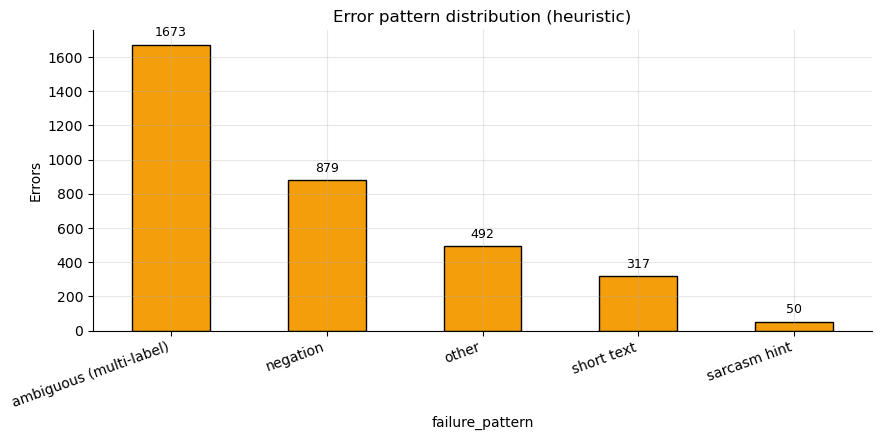

In [20]:
def labels_from_vector(vec):
    return [label_cols[i] for i, v in enumerate(vec) if v == 1]

error_rows = []
for i in range(len(test_df)):
    true_l, pred_l = set(labels_from_vector(y_test[i])), set(labels_from_vector(y_test_pred_lr[i]))
    if true_l != pred_l:
        error_rows.append({"index": i, "text": test_df.iloc[i]["text"],
                           "true_labels": sorted(true_l), "predicted_labels": sorted(pred_l),
                           "text_length": len(str(test_df.iloc[i]["text"]).split())})
errors_df = pd.DataFrame(error_rows)
print(f"Errors: {len(errors_df)} / {len(test_df)} ({len(errors_df)/len(test_df):.1%})")

def classify_pattern(row):
    text = str(row["text"]).lower()
    if row["text_length"] <= 4: return "short text"
    if any(w in text for w in [" not ", "n't", "no ", "never"]): return "negation"
    if any(w in text for w in ["yeah right", "sure", "/s", "great...", "wonderful..."]): return "sarcasm hint"
    if len(row["true_labels"]) > 1 or len(row["predicted_labels"]) > 1: return "ambiguous (multi-label)"
    return "other"

errors_df["failure_pattern"] = errors_df.apply(classify_pattern, axis=1)
failure_counts = errors_df["failure_pattern"].value_counts()
ax = failure_counts.plot(kind="bar", figsize=(9, 4.5), color="#f59e0b", edgecolor="black")
ax.set_title("Error pattern distribution (heuristic)"); ax.set_ylabel("Errors")
for i, v in enumerate(failure_counts.values): ax.text(i, v + 50, str(v), ha="center", fontsize=9)
plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig(FIGURE_DIR / "error_patterns.png", dpi=200, bbox_inches="tight"); plt.show()

### 5.8 Torture test: hand-crafted edge cases


In [21]:
torture = [
    ("I am so happy and excited about this!", ["joy"]),
    ("This is absolutely disgusting and I hate it.", ["disgust", "anger"]),
    ("I feel nervous and scared about what will happen.", ["fear"]),
    ("I miss them so much, my heart is broken.", ["sadness"]),
    ("Wait, what?! I can't believe this happened.", ["surprise"]),
    ("The weather is fine today.", ["neutral"]),
    ("Oh great, another wonderful Monday morning.", ["sadness", "anger"]),   # sarcasm
    ("I'm not unhappy about it.", ["joy", "neutral"]),                       # double negation
    ("Lol", ["joy"]),                                                        # very short
    ("I'm furious but also kind of relieved it's over.", ["anger", "joy"]),  # mixed
]
for text, expected in torture:
    cleaned = preprocess_text(text)
    if not cleaned:
        print(f"? {text} -> (empty after cleaning)"); continue
    probs = lr_clf.predict_proba(tfidf_vectorizer.transform([cleaned]))[0]
    preds = [label_cols[i] for i, p in enumerate(probs) if p >= 0.5] or ["(none>0.5)"]
    ok = "OK " if set(expected) & set(preds) else "MISS"
    print(f"{ok} | {text}\n      expected={expected} pred={preds}")

OK  | I am so happy and excited about this!
      expected=['joy'] pred=['joy']
OK  | This is absolutely disgusting and I hate it.
      expected=['disgust', 'anger'] pred=['anger', 'disgust']
OK  | I feel nervous and scared about what will happen.
      expected=['fear'] pred=['fear']
OK  | I miss them so much, my heart is broken.
      expected=['sadness'] pred=['sadness', 'neutral']
OK  | Wait, what?! I can't believe this happened.
      expected=['surprise'] pred=['surprise']
OK  | The weather is fine today.
      expected=['neutral'] pred=['neutral']
MISS | Oh great, another wonderful Monday morning.
      expected=['sadness', 'anger'] pred=['joy']
OK  | I'm not unhappy about it.
      expected=['joy', 'neutral'] pred=['surprise', 'neutral']
OK  | Lol
      expected=['joy'] pred=['joy']
MISS | I'm furious but also kind of relieved it's over.
      expected=['anger', 'joy'] pred=['neutral']


**Highlights: Direct emotion words ("happy", "scared") are detected reliably.** Sarcasm and double negations fail: words like "great" and "wonderful" are scored as joy even in clearly negative sentences.


### 5.9 Top contributing words (LogReg coefficients)

The bar chart shows the top words for each emotion by logistic regression coefficient. Positive words like `love` and `thank` push toward **joy**, strong negative words push toward **anger**, and so on. These weights are also used in the `explain_prediction` demo in 6, so the chart and the demo always agree.


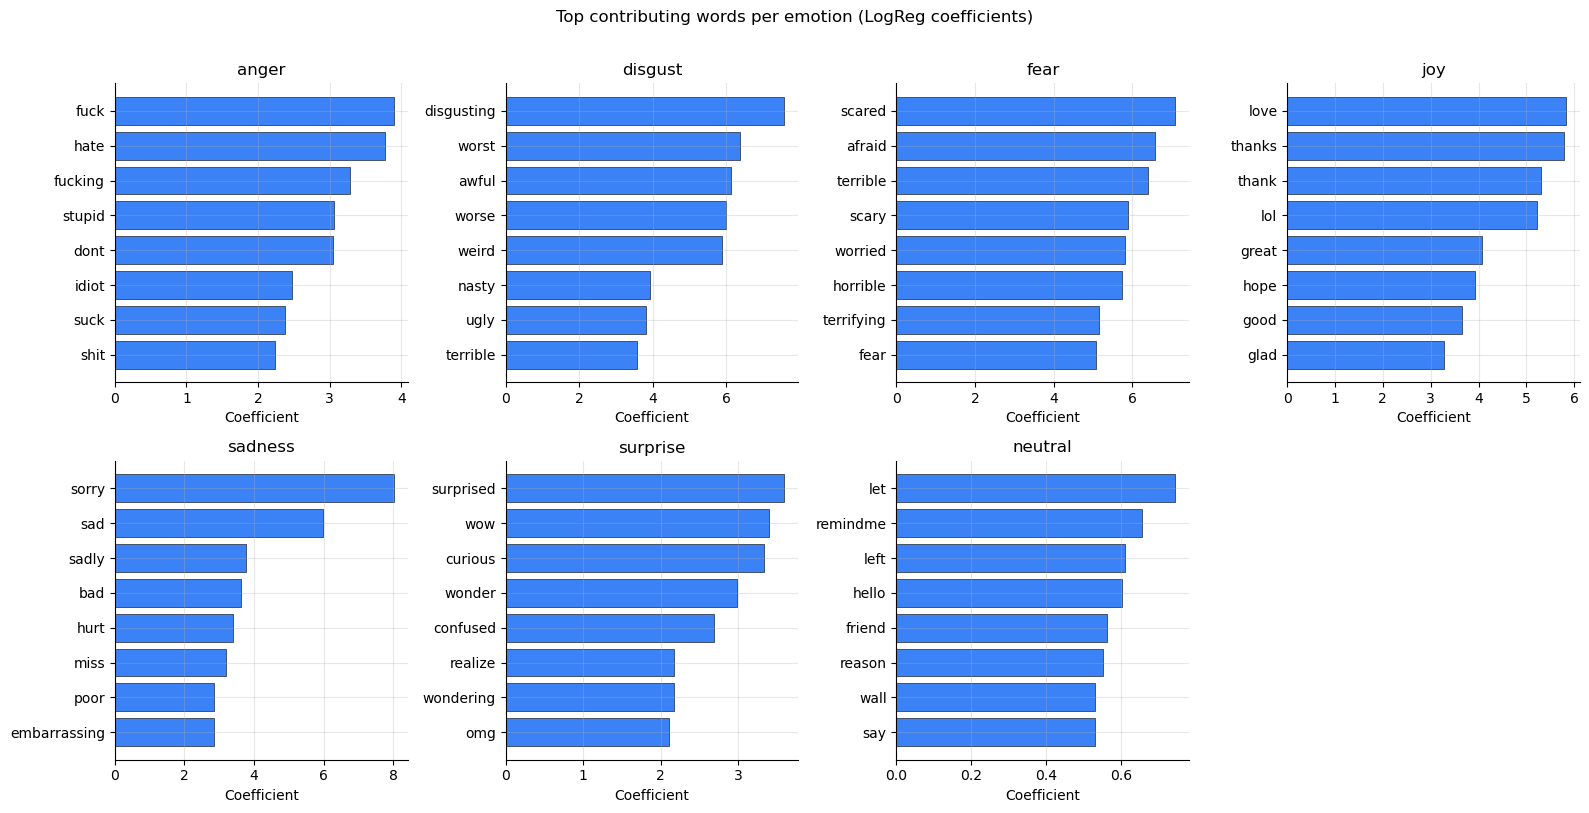

In [22]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
lr_coefs = np.vstack([est.coef_[0] for est in lr_clf.estimators_])

fig, axes = plt.subplots(2, 4, figsize=(16, 8)); axes = axes.flatten()
for i, emotion in enumerate(label_cols):
    top_idx = np.argsort(-lr_coefs[i])[:8]
    words = feature_names[top_idx]; coefs = lr_coefs[i, top_idx]
    axes[i].barh(words[::-1], coefs[::-1], color="#3b82f6", edgecolor="black", linewidth=0.4)
    axes[i].set_title(emotion); axes[i].set_xlabel("Coefficient")
axes[-1].axis("off")
plt.suptitle("Top contributing words per emotion (LogReg coefficients)", y=1.01)
plt.tight_layout(); plt.savefig(FIGURE_DIR / "top_words.png", dpi=200, bbox_inches="tight"); plt.show()

---
## 6. Interpretability demo

Because we use a linear model, each prediction is explained by the TF-IDF word weights multiplied by the logistic coefficients. You can change `INPUT_TEXT` and rerun the cell to see which words drove the prediction. This is the main reason we chose TF-IDF over a neural embedding model.


In [23]:
def explain_prediction(text, top_k_words=5, threshold=0.5):
    cleaned = preprocess_text(text)
    if not cleaned:
        print("Empty input after preprocessing."); return
    x = tfidf_vectorizer.transform([cleaned])
    probs = lr_clf.predict_proba(x)[0]
    ranked = sorted(zip(label_cols, probs), key=lambda kv: -kv[1])

    print("=" * 60); print(f"INPUT:   {text}"); print(f"CLEANED: {cleaned}"); print("=" * 60)
    for emo, p in ranked:
        print(f"  {emo:<10} {p:.3f} {'<-- predicted' if p >= threshold else ''}")

    x_dense = x.toarray()[0]; active = np.where(x_dense > 0)[0]
    if len(active) == 0:
        print("No vocabulary words matched."); return
    predicted = [e for e, p in ranked if p >= threshold] or [ranked[0][0]]
    print("\nWord contributions:")
    for emo in predicted:
        ei = label_cols.index(emo)
        contribs = x_dense[active] * lr_coefs[ei, active]
        order = np.argsort(-contribs)[:top_k_words]
        print(f"  {emo.upper()}:")
        for i in order:
            w, c = feature_names[active[i]], contribs[i]
            bar = ("#" if c > 0 else ".") * int(min(abs(c) * 100, 30))
            print(f"    {w:<18} {'+' if c>0 else '-'}{abs(c):.3f}  {bar}")


In [24]:
INPUT_TEXT = "This class was amazing! We learned a lot of things!"
explain_prediction(INPUT_TEXT)

INPUT:   This class was amazing! We learned a lot of things!
CLEANED: class amazing learned lot thing
  joy        0.668 <-- predicted
  surprise   0.421 
  neutral    0.348 
  anger      0.330 
  fear       0.300 
  sadness    0.277 
  disgust    0.235 

Word contributions:
  JOY:
    amazing            +1.006  ##############################
    lot                +0.171  #################
    learned            +0.089  ########
    class              +0.049  ####
    thing              -0.012  .


In [25]:
# Sarcasm known TF-IDF failure mode
INPUT_TEXT = "Oh great, another wonderful Monday morning. Just what I needed."
explain_prediction(INPUT_TEXT)

INPUT:   Oh great, another wonderful Monday morning. Just what I needed.
CLEANED: great another wonderful monday morning needed
  joy        0.793 <-- predicted
  neutral    0.311 
  surprise   0.252 
  sadness    0.249 
  anger      0.230 
  disgust    0.176 
  fear       0.141 

Word contributions:
  JOY:
    great              +1.254  ##############################
    wonderful          +0.535  ##############################
    morning            +0.116  ###########
    monday             +0.013  #
    needed             -0.004  


---
## 7. Conclusions & Future Work

### What worked
- Logistic regression with balanced weights roughly **doubles macro-F1** over Naive Bayes (0.25 to 0.50).
- The **joy** class reaches F1 above 0.7, making it usable in practice for plain-language comments.
- All outputs (coefficient plots, confusion matrices, the live demo) trace back to the same model weights, giving full interpretability.
- K-means, DBSCAN, and the 300-dim SVD control all agree: TF-IDF space has no clean cluster structure, so supervised learning is necessary.

### Known limitations
1. Fixed **0.5 thresholds** for all classes. Per-class threshold tuning could improve precision.
2. **TF-IDF ignores context**: negation, sarcasm, and meme language cause predictable failures (see 5.7-5.8).
3. **Rare emotions** (disgust, fear) still have very few training examples even after the Ekman collapse.
4. The poor clustering result reflects the limits of TF-IDF, not that emotions are undetectable. Better embeddings would likely cluster better.

### Next steps
1. Per-class threshold tuning using the validation PR curves.
2. Test a lightweight transformer (e.g., DistilBERT) and compare results directly against this notebook.
3. Augment training data for sarcasm and negation patterns rather than just adding more TF-IDF features.


## 8. Resources & Reproducibility

All code, the processed data splits, and saved models are available at: https://github.com/fammad/EmotionRadar . The notebook runs top-to-bottom; it loads pre-saved CSVs from data/processed/ and falls back to downloading GoEmotions from HuggingFace if they're absent.

**Reproducibility notes:**
Random seed fixed (RANDOM_STATE = 42) for all stochastic steps (train/val/test split, K-Means init, t-SNE, sampling).
TF-IDF vectorizer fit on training data only; val/test transformed with the same vocabulary (no leakage).
Trained models and the fitted vectorizer are saved to data/models/ (nb_model.pkl, lr_model.pkl, tfidf.pkl).

**Libraries:** 
scikit-learn (TF-IDF, MultinomialNB, LogisticRegression, TruncatedSVD, KMeans, DBSCAN, t-SNE, metrics)
NLTK (stopwords, WordNet lemmatizer)
NumPy, pandas, Matplotlib, seaborn

**References / background reading:**
>Demszky, D. et al. (2020). GoEmotions: A Dataset of Fine-Grained Emotions. ACL 2020. Accessed via the HuggingFace go_emotions (simplified) configuration.
>
>Ekman, P. (1992). An Argument for Basic Emotions.  justifies the 7-category remap.
scikit-learn documentation: multiclass/multilabel, clustering, TruncatedSVD (LSA).
Géron, A. Hands-On Machine Learning. course textbook, general reference.
